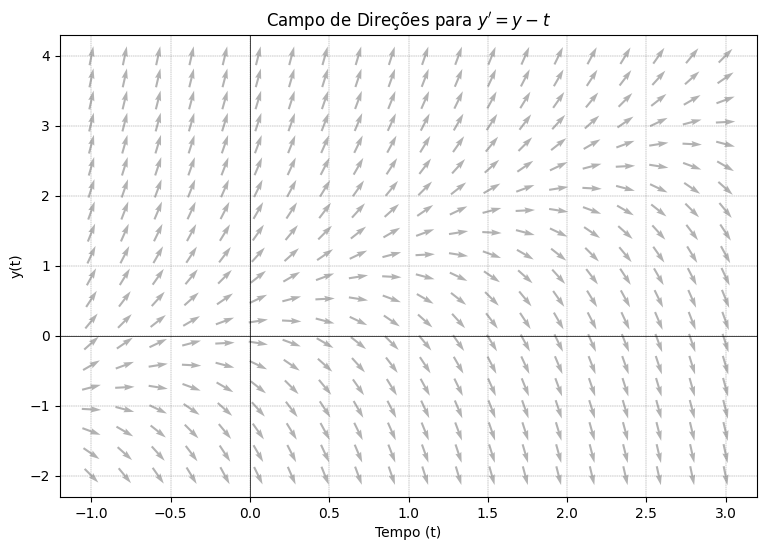

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo a ED: y' = f(t, y)
def f(t, y):
    return y - t

# Criando uma grade de pontos no plano (t, y)
t_grid = np.linspace(-1, 3, 20)
y_grid = np.linspace(-2, 4, 20)
T, Y = np.meshgrid(t_grid, y_grid)

# Calculando a inclinação em cada ponto da grade
# Para o quiver (gráfico de setas), o vetor direção é (1, y')
dT = np.ones(T.shape) 
dY = f(T, Y)

# Normalizando os vetores para que todas as setinhas tenham o mesmo tamanho (estética)
L = np.sqrt(dT**2 + dY**2)
dT_norm = dT / L
dY_norm = dY / L

# Plotando o Campo de Direções
plt.figure(figsize=(9, 6))
plt.quiver(T, Y, dT_norm, dY_norm, color='gray', alpha=0.6, pivot='mid')
plt.title("Campo de Direções para $y' = y - t$")
plt.xlabel("Tempo (t)")
plt.ylabel("y(t)")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(color='gray', linestyle='--', linewidth=0.3)
plt.show()

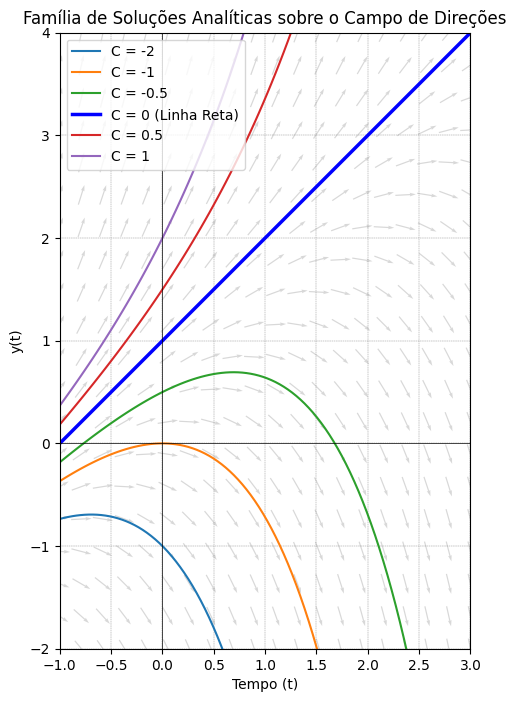

In [2]:
# Criando um vetor de tempo mais denso para o traçado suave das curvas exatas
t_smooth = np.linspace(-1, 3, 100)

# Redesenhando o campo de direções (com as correções geométricas)
plt.figure(figsize=(8, 8))
plt.quiver(T, Y, dT_norm, dY_norm, color='gray', alpha=0.3, pivot='mid', 
           angles='xy', scale_units='xy', scale=5)

# Valores de C que queremos testar
valores_C = [-2, -1, -0.5, 0, 0.5, 1]

# Plotando a família de soluções exatas
for C in valores_C:
    # A fórmula da nossa solução analítica
    y_exato = t_smooth + 1 + C * np.exp(t_smooth)
    
    # Vamos destacar a curva onde C=0
    if C == 0:
        plt.plot(t_smooth, y_exato, 'b-', linewidth=2.5, label='C = 0 (Linha Reta)')
    else:
        plt.plot(t_smooth, y_exato, linewidth=1.5, label=f'C = {C}')

plt.title("Família de Soluções Analíticas sobre o Campo de Direções")
plt.xlabel("Tempo (t)")
plt.ylabel("y(t)")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# Travando os limites para não deformar o gráfico com exponenciais explodindo
plt.xlim(-1, 3)
plt.ylim(-2, 4)

# Aspect ratio 1:1 e legenda
plt.gca().set_aspect('equal')
plt.legend(loc='upper left')
plt.grid(color='gray', linestyle='--', linewidth=0.3)
plt.show()

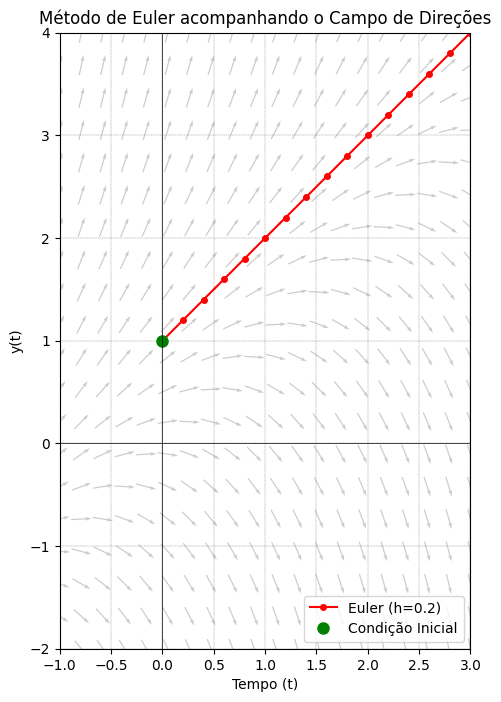

In [3]:
# Implementação do Método de Euler
def euler_method(f, t0, y0, h, n_steps):
    t_vals = np.zeros(n_steps + 1)
    y_vals = np.zeros(n_steps + 1)
    
    t_vals[0] = t0
    y_vals[0] = y0
    
    for i in range(n_steps):
        # Calcula a inclinação atual
        slope = f(t_vals[i], y_vals[i])
        
        # Dá o passo de tamanho h
        t_vals[i+1] = t_vals[i] + h
        y_vals[i+1] = y_vals[i] + h * slope
        
    return t_vals, y_vals

# Vamos simular começando em y(0) = 1, com passo h=0.2
t0, y0 = 0, 1
h = 0.2
n_steps = 15

t_euler, y_euler = euler_method(f, t0, y0, h, n_steps)

# Redesenhando o campo e colocando a solução do Euler por cima
plt.figure(figsize=(8, 8)) # Deixamos mais quadrada para uma visualização geométrica ideal

# CORREÇÃO: angles='xy' garante que a seta siga os dados, e scale_units ajusta o tamanho
plt.quiver(T, Y, dT_norm, dY_norm, color='gray', alpha=0.4, pivot='mid', 
           angles='xy', scale_units='xy', scale=5)

# Plotando os passos do método de Euler
plt.plot(t_euler, y_euler, 'ro-', label=f'Euler (h={h})', markersize=4)
plt.plot(t0, y0, 'go', label='Condição Inicial', markersize=8) # Ponto inicial verde

plt.title("Método de Euler acompanhando o Campo de Direções")
plt.xlabel("Tempo (t)")
plt.ylabel("y(t)")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-1, 3)
plt.ylim(-2, 4)
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.3)

# CORREÇÃO 2 (Opcional, mas muito didática): Força os eixos a terem a mesma escala visual
plt.gca().set_aspect('equal')

plt.show()